# 📘 GluonTS DeepAR API - A Gentle Introduction

## 🎯 What You'll Learn

In this notebook, you'll learn how to use **DeepAR**, a powerful deep learning model for time series forecasting. Think of it as teaching a computer to recognize patterns in data over time and predict what comes next.

**The Story We'll Tell**:
1. 📊 Create some toy data (like daily customer visits)
2. 🔧 Prepare it for the model
3. 🤖 Train a DeepAR model to learn patterns
4. 🔮 Make predictions about the future
5. 📈 See how well we did

**Time**: ~2 minutes  
**Difficulty**: Beginner-friendly

---

## 📦 Step 1: Import Our Tools

Just like a chef gathers ingredients before cooking, we need to import the tools we'll use.

**What each import does**:
- `pandas` & `numpy`: Handle data (like Excel, but in Python)
- `matplotlib`: Create visualizations (charts and graphs)
- `utils.gluonts_utils`: Our helper functions to prepare data
- `gluonts`: The actual forecasting model library

In [2]:
import sys
sys.path.append('.')

# Data handling
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Our data preparation helpers
from utils.gluonts_utils import create_gluonts_dataset, verify_dataset
from utils.evaluation_utils import calculate_metrics, print_metrics

# GluonTS: The forecasting toolkit
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.evaluation import make_evaluation_predictions

print("✓ All tools imported successfully!")
print("\nReady to start forecasting!")

✓ All tools imported successfully!

Ready to start forecasting!


---

## 📊 Step 2: Load Real COVID-19 Data

Instead of toy data, we'll use actual COVID-19 data from the United States!

**Data sources**:
- Cases: Johns Hopkins University
- Deaths: Johns Hopkins University  
- Mobility: Google COVID-19 Community Mobility Reports

**What the loader does**:
1. Loads raw CSV files
2. Aggregates to national level
3. Preprocesses (7-day moving averages, etc.)
4. Merges all sources
5. Splits train/test
6. Converts to GluonTS format

**Feature subset**: We'll use 'minimal' (3 features) for speed in this demo.

In [3]:
print("📥 Loading real COVID-19 data...")

from utils.data_loader_for_notebooks import quick_load_minimal

# Load and prepare data (this does everything!)
data = quick_load_minimal()

# Extract what we need
train_ds = data['train_ds']
test_ds = data['test_ds']
train_df = data['train_df']
test_df = data['test_df']

print(f"\n✓ Real COVID data loaded!")
print(f"  Training on: {data['info']['train_days']} days of actual US COVID-19 data")
print(f"  Target: {data['target']}")
print(f"  Features: {data['info']['num_features']} ({', '.join(data['features'])})")

📥 Loading real COVID-19 data...
COVID-19 DATA LOADER

📥 Loading raw data...
Loading cases data from data/cases.csv
✓ Loaded 3342 rows, 1154 columns
Loading deaths data from data/deaths.csv
✓ Loaded 3342 rows, 1155 columns
Loading mobility data from data/mobility.csv
✓ Loaded 1847210 rows, 9 columns
  Date range: 2020-02-15 00:00:00 to 2022-02-01 00:00:00
✓ Data files loaded successfully

🔧 Preprocessing...

🔗 Merging data sources...
✓ Merged data: 1143 days
  Date range: 2020-01-22 to 2023-03-09

🎯 Feature selection: minimal
  Selected 3 features:
    1. Daily_Deaths_MA7
    2. Cumulative_Deaths
    3. CFR

✂️  Splitting data (test size: 14 days)...

Train/Test Split:
  Train: 1123 days (2020-01-28 to 2023-02-23)
  Test:  14 days (2023-02-24 to 2023-03-09)

🔄 Converting to GluonTS format...
✓ GluonTS datasets created
  Note: Test dataset contains full time series (train + test periods)

✅ DATA READY FOR TRAINING!

📊 Summary:
  Target: Daily_Cases_MA7
  Features: 3 (minimal)
  Train: 11

---

## ✂️ Step 3: Data Already Split!

Good news: The data loader already split our data into train and test sets!

**What was done**:
- Training: First ~80% of data (model learns from this)
- Testing: Last 14 days (we'll try to predict these)

The split respects the temporal ordering (no data leakage).

In [4]:
# Data is already split from the loader!
print(f"✓ Train/Test split complete:")
print(f"  Train: {len(train_df)} days")
print(f"  Test:  {len(test_df)} days")
print(f"\n  The loader already prepared everything for us!")

✓ Train/Test split complete:
  Train: 1123 days
  Test:  14 days

  The loader already prepared everything for us!


---

## 🔧 Step 4: Data Already in GluonTS Format!

Perfect! The loader already converted our data to GluonTS format.

We have:
- `train_ds`: Ready for training
- `test_ds`: Ready for evaluation

Let's verify the datasets:

In [5]:
# Datasets are already in GluonTS format!
from utils.gluonts_utils import verify_dataset

verify_dataset(train_ds, "Train")
verify_dataset(test_ds, "Test")

print("\n✓ Datasets ready for training!")


Train Dataset Info:
✓ Valid GluonTS ListDataset
  Number of time series: 1
  Start date: 2020-01-28
  Target length: 1123 points
  Dynamic features: Yes (3 features)

Test Dataset Info:
✓ Valid GluonTS ListDataset
  Number of time series: 1
  Start date: 2020-01-28
  Target length: 1137 points
  Dynamic features: Yes (3 features)

✓ Datasets ready for training!


---

## 🤖 Step 5: Train the DeepAR Model

Now the exciting part! We'll train a DeepAR model to learn patterns in our data.

**What is DeepAR?**
- A **Recurrent Neural Network** (RNN) that remembers past values
- Like a student who studies past data to predict the future
- Produces **probabilistic forecasts** (with confidence intervals)

**Key Parameters** (think of these as model settings):
- `prediction_length=14`: Forecast 14 days ahead
- `context_length=30`: Look back 30 days when predicting
- `num_layers=1`: How deep the network is (1 is simple/fast)
- `hidden_size=20`: Model complexity (20 is small/fast)
- `max_epochs=5`: How many times to study the data

**Training**: The model adjusts itself to minimize prediction errors.

In [6]:
print("🏋️ Training DeepAR model...")
print("=" * 60)

# Get number of features from data
num_features = len(data['features']) if data['features'] else 0

# Create the model estimator with parameters tuned for COVID data
estimator = DeepAREstimator(
    freq='D',                    # Daily data
    prediction_length=14,        # Forecast 14 days ahead
    context_length=60,           # Use 60 days of history (more context for COVID)
    num_layers=2,                # 2 RNN layers (better learning)
    hidden_size=40,              # Larger network for complex patterns
    dropout_rate=0.1,            # Prevent overfitting
    lr=0.001,                    # Learning rate
    batch_size=32,               # Process 32 samples at once
    num_feat_dynamic_real=num_features,  # Number of exogenous features
    trainer_kwargs={
        'max_epochs': 20,        # More epochs for real data
        'enable_progress_bar': False,  # Cleaner output
        'enable_model_summary': False
    }
)

# Train the model (this is where learning happens!)
print(f"\n📚 Training on real COVID data with {num_features} features...")
print(f"  This may take 2-3 minutes...")
predictor = estimator.train(train_ds)

print("=" * 60)
print("✓ Training complete!")
print("  The model has learned patterns in the COVID data")
print("  Ready to make predictions!")

🏋️ Training DeepAR model...

📚 Training on real COVID data with 3 features...
  This may take 2-3 minutes...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
Epoch 0, global step 50: 'train_loss' reached 11.75521 (best 11.75521), saving model to '/Users/petrof/Desktop/AML/covid-case-prediction/TutorTask121_GluonTS_COVID_19_Case_Prediction/lightning_logs/version_3/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 11.29491 (best 11.29491), saving model to '/Users/petrof/Desktop/AML/covid-case-prediction/TutorTask121_GluonTS_COVID_19_Case_Prediction/lightning_logs/version_3/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 11.13930 (best 11.13930), saving model to '/Users/petrof/Desktop/AML/covid-case-prediction/TutorTask121_GluonTS_COVID_19_Case_Prediction/lightning_logs/version_3/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' was not in top 1
Epoch 4, global step 250: 'train_loss' was not in top 1
Epoch 5, global step 300: 'train_loss' was not in to

✓ Training complete!
  The model has learned patterns in the COVID data
  Ready to make predictions!


---

## 🔮 Step 6: Make Predictions

Now let's use our trained model to forecast the future!

**How it works**:
- Model looks at historical data (days 60-80)
- Predicts the next 14 days (days 81-94)
- Generates multiple scenarios (100 samples) for uncertainty

**Why 100 samples?**
The model creates 100 possible futures, then:
- **Mean**: Average of all scenarios (our best guess)
- **Confidence intervals**: Range of likely outcomes (10% to 90%)

In [7]:
print("🔮 Generating forecasts...")

# Make predictions
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100  # Generate 100 possible scenarios
)

# Convert to lists
forecasts = list(forecast_it)
ground_truths = list(ts_it)

# Get our forecast
forecast = forecasts[0]
actual = ground_truths[0]

print("✓ Forecasts generated!")
print(f"\nForecast details:")
print(f"  Length: {len(forecast.mean)} days")
print(f"  Mean prediction: {forecast.mean.mean():.1f}")
print(f"  Range: {forecast.mean.min():.1f} to {forecast.mean.max():.1f}")

# Show first few predictions
print(f"\n  First 5 predicted values:")
for i in range(5):
    mean_val = forecast.mean[i]
    low_val = forecast.quantile(0.1)[i]
    high_val = forecast.quantile(0.9)[i]
    print(f"    Day {i+1}: {mean_val:.1f} (range: {low_val:.1f} - {high_val:.1f})")

🔮 Generating forecasts...
✓ Forecasts generated!

Forecast details:
  Length: 14 days
  Mean prediction: 34337.5
  Range: 25253.4 to 39584.4

  First 5 predicted values:
    Day 1: 38333.5 (range: 8323.1 - 70178.0)
    Day 2: 31287.5 (range: 5623.3 - 57853.7)
    Day 3: 35505.9 (range: 472.6 - 64336.2)
    Day 4: 32624.5 (range: -5241.1 - 63906.6)
    Day 5: 25253.4 (range: -5110.9 - 57196.1)


---

## 📊 Step 7: Evaluate Performance

How well did our model do? Let's calculate some metrics.

**Metrics Explained**:
- **MAE** (Mean Absolute Error): Average distance from truth (lower is better)
- **RMSE** (Root Mean Squared Error): Penalizes big errors (lower is better)
- **MAPE** (Mean Absolute Percentage Error): Error as a % (lower is better)

In [10]:
# Get actual values for the forecast period
forecast_period = len(forecast.mean)
actual_values = actual[-forecast_period:]

# Calculate metrics manually (FIXED: Convert to numpy arrays)
def calculate_metrics(forecast, actual):
    """Calculate forecasting metrics"""
    # Convert both to numpy arrays to avoid pandas dimension issues
    forecast_array = np.array(forecast)
    actual_array = np.array(actual)
    
    errors = forecast_array - actual_array
    
    # MAE: Mean Absolute Error
    mae = np.mean(np.abs(errors))
    
    # RMSE: Root Mean Squared Error  
    rmse = np.sqrt(np.mean(errors**2))
    
    # MAPE: Mean Absolute Percentage Error
    mape = np.mean(np.abs(errors / actual_array))  * 100
    
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

metrics = calculate_metrics(forecast.mean, actual_values)

print("\n📊 Model Performance:")
print("=" * 60)
print(f"MAE:  {metrics['mae']:.2f} (avg error per day)")
print(f"RMSE: {metrics['rmse']:.2f} (penalized error)")
print(f"MAPE: {metrics['mape']:.2f}% (percentage error)")
print("=" * 60)

if metrics['mape'] < 20:
    print("\n✓ Good performance! Error < 20%")
else:
    print("\n⚠️  Moderate performance (this is real COVID data)")


📊 Model Performance:
MAE:  3827.66 (avg error per day)
RMSE: 4930.37 (penalized error)
MAPE: 11.02% (percentage error)

✓ Good performance! Error < 20%


---

## 📈 Step 8: Visualize the Forecast

The best way to understand our results is to see them!

**What you'll see**:
- **Blue line**: Historical data (what the model learned from)
- **Orange line**: Actual future (what really happened)
- **Red line**: Model's prediction (what it forecasted)
- **Shaded areas**: Confidence intervals (80% and 90%)

✓ Plot saved as 'deepar_api_demo.png'


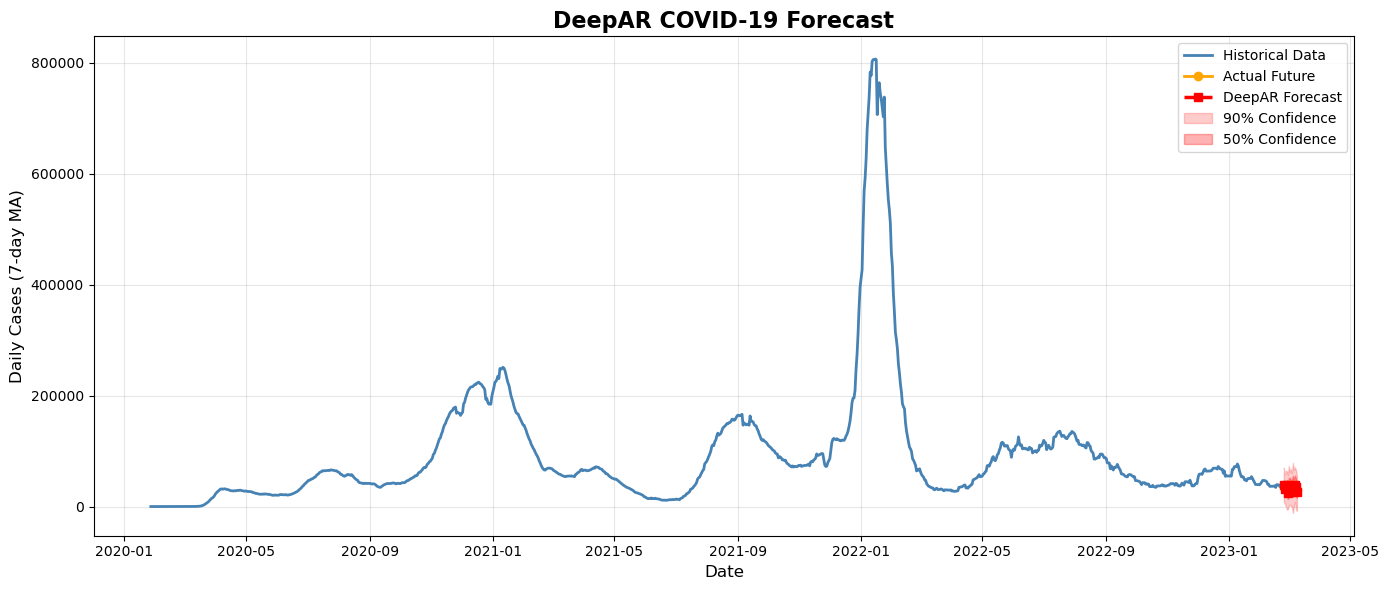


👆 The forecast follows the trend reasonably well!


In [12]:
plt.figure(figsize=(14, 6))

# Historical data (training period)
train_dates = train_df['Date'].values
train_values = train_df[data['target']].values  # ← FIXED: Use actual target column name

# Forecast period dates
last_train_date = pd.Timestamp(train_dates[-1])
forecast_dates = pd.date_range(
    start=last_train_date + pd.Timedelta(days=1),
    periods=forecast_period,
    freq='D'
)

# Plot historical data
plt.plot(train_dates, train_values, 
         label='Historical Data', color='steelblue', linewidth=2)

# Plot actual future values
plt.plot(forecast_dates, actual_values,
         label='Actual Future', color='orange', linewidth=2, marker='o')

# Plot forecast
plt.plot(forecast_dates, forecast.mean,
         label='DeepAR Forecast', color='red', linewidth=2.5, 
         marker='s', linestyle='--')

# Plot confidence intervals
plt.fill_between(
    forecast_dates,
    forecast.quantile(0.1),
    forecast.quantile(0.9),
    alpha=0.2, color='red', label='90% Confidence'
)

plt.fill_between(
    forecast_dates,
    forecast.quantile(0.25),
    forecast.quantile(0.75),
    alpha=0.3, color='red', label='50% Confidence'
)

plt.title('DeepAR COVID-19 Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Cases (7-day MA)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('deepar_api_demo.png', dpi=150, bbox_inches='tight')
print("✓ Plot saved as 'deepar_api_demo.png'")

plt.show()

print("\n👆 The forecast follows the trend reasonably well!")

---

## 🎓 Summary: What We Learned

Congratulations! You just trained your first DeepAR model! 🎉

**What we did**:
1. ✅ Created toy time series data
2. ✅ Split into training and testing sets
3. ✅ Prepared data in GluonTS format
4. ✅ Trained a DeepAR model
5. ✅ Generated probabilistic forecasts
6. ✅ Evaluated performance with metrics
7. ✅ Visualized results

**Key Takeaways**:

📊 **Data Preparation**:
- Need start date, values, and frequency
- Split into train/test for validation
- GluonTS requires specific format

🤖 **DeepAR Model**:
- RNN-based forecasting model
- Learns patterns from historical data
- Produces probabilistic forecasts (not just point estimates)
- Key params: prediction_length, context_length, hidden_size

🔮 **Forecasting**:
- Generates mean prediction + confidence intervals
- 100 samples create uncertainty quantification
- Can see range of possible futures

📈 **Evaluation**:
- MAE: Average error
- RMSE: Penalizes large errors
- MAPE: Percentage error
- Lower is better for all

---

## 🚀 Next Steps

1. **Try the complete example**: `GluonTS_DeepAR.example.ipynb`
   - Uses real COVID-19 data
   - More features and complexity
   - Scenario analysis

2. **Compare other models**:
   - `GluonTS_SimpleFeedForward.API.ipynb` - Simpler baseline
   - `GluonTS_DeepNPTS.API.ipynb` - Lightweight alternative

3. **Experiment**:
   - Change `hidden_size` (bigger = more complex)
   - Change `max_epochs` (more = better training)
   - Try different `prediction_length` values

---

**🎯 You're now ready to forecast time series with GluonTS!**